# ReAct Agent 만들기
- ReAct(Reasoning + Acting)는 대화형 AI가 복잡한 문제를 해결할 때 사용하는 프롬프팅 기법입니다.

![img](https://substackcdn.com/image/fetch/$s_!jFpt!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F6b27a8a7-8f67-4558-a3f4-44bf512e6c92_1766x812.gif)

## ReAct Agent란?

**ReAct = Reasoning + Acting**
- **Reasoning (추론)**: 문제를 분석하고 다음 단계를 계획
- **Acting (행동)**: 실제로 도구를 사용하여 정보 수집이나 작업 수행
- **Observation (관찰)**: 행동의 결과를 확인하고 다음 추론에 활용

이 과정을 반복하여 최종 답안에 도달합니다.

### 도구 설계 원칙

1. **단일 책임**: 각 도구는 하나의 명확한 기능을 수행해야 합니다.
2. **명확한 문서화**: 도구의 목적과 사용법을 명확히 문서화합니다.
3. **오류 처리**: 예상 가능한 오류 상황에 대한 적절한 처리를 포함합니다.
4. **타입 힌트**: 입력 매개변수의 타입을 명확히 지정합니다.

### 실제 활용 사례

- **데이터 분석**: 웹 검색 + 계산 + 텍스트 분석
- **콘텐츠 생성**: 검색 + 요약 + 저장
- **업무 자동화**: 스케줄링 + 알림 + 데이터 처리
- **학습 보조**: 질문 + 검색 + 설명 생성

# [LangGraph를 활용한 ReAct Agent 만들기](https://docs.langchain.com/oss/python/langgraph/workflows-agents#agents)


## 1단계: 환경 설정

- [OpenAI API Key](https://platform.openai.com/api-keys)
- [Tavily API Key](https://app.tavily.com/home)
- [Langsmith API Key](https://smith.langchain.com/)

In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

## 2단계: 그래프 상태 정의하기

LangGraph에서는 에이전트의 상태를 정의해야 합니다. 상태는 그래프 실행 중에 노드들 간에 공유되는 데이터입니다.

### 상태(State)란?
- 에이전트가 실행되는 동안 **메모리 역할**을 하는 데이터 구조
- 각 노드에서 **읽고 쓸 수 있는** 공통 저장소
- **메시지 기록, 계산 결과, 중간 상태** 등을 저장


In [2]:
from typing import Annotated, Sequence, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

# 에이전트 상태 정의
class AgentState(TypedDict):
    """
    ReAct 에이전트의 상태를 정의합니다.
    """
    # add_messages는 리듀서(reducer) 함수입니다
    # 이는 새로운 메시지들을 기존 메시지 리스트에 자동으로 추가해줍니다
    messages: Annotated[Sequence[BaseMessage], add_messages]


## 3단계: 모델과 도구 정의하기

이제 ReAct Agent가 사용할 AI 모델과 도구들을 정의합니다.


### 모델이란?
- GPT, Claude 등 **언어 모델**
- 추론과 응답 생성을 담당

In [3]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### 도구(Tools)란?
- Agent가 **외부 정보에 접근**하거나 **특정 작업을 수행**할 수 있게 해주는 함수
- 예: 날씨 조회, 계산기, 웹 검색, 데이터베이스 조회 등

In [4]:
from langchain_tavily import TavilySearch

search_weather = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=False,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="basic",          # "basic" 또는 "advanced"
    include_domains=[
        "https://weather.daum.net/",
        "https://www.weatheri.co.kr/" 
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [5]:
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """특정 도시의 현재 날씨 정보를 검색합니다."""
    try:
        search_query = f"{city} 현재 날씨 기온"
        result_weather = search_weather.invoke(search_query)
        
        if not result_weather['answer'] or len(result_weather['results']) < 1:
            return f"'{city}'의 날씨 정보를 찾을 수 없습니다."
        
        # 첫 번째 결과에서 날씨 정보 추출
        answer = model.invoke(f"{result_weather['answer']} 설명없이 한문장으로 번역해줘.")
        weather_info = f"""
        {city} 날씨 정보:
        {answer.content}

        출처: {result_weather['results'][0]['url']}
        """
        
        return weather_info
        
    except Exception as e:
        return f"날씨 정보 검색 중 오류가 발생했습니다: {str(e)}"

In [6]:
import subprocess
import sys

@tool
def calculator(expression: str) -> str:
    """
    수학 계산을 수행하는 도구입니다.
    """
    try:
        # 안전을 위해 허용된 문자만 통과
        allowed_chars = "0123456789+-*/.%() "
        if not all(c in allowed_chars for c in expression):
            return "오류: 허용되지 않는 문자가 포함되어 있습니다."

        python_exec = "python3" if sys.platform != "win32" else "python"

        # subprocess를 이용해 별도 Python 프로세스에서 계산 수행
        result = subprocess.run(
            [python_exec, "-c", f"print({expression})"],
            capture_output=True,
            text=True,
            timeout=3  # 무한 루프 방지
        )

        if result.returncode != 0:
            return f"계산 오류: {result.stderr.strip()}"
        
        return f"계산 결과: {expression} = {result.stdout.strip()}"

    except subprocess.TimeoutExpired:
        return "계산 오류: 계산이 너무 오래 걸립니다."
    except Exception as e:
        return f"계산 오류: {str(e)}"

In [7]:
@tool
def get_current_time() -> str:
    """
    현재 시간을 조회합니다.
    """
    import datetime
    now = datetime.datetime.now()
    return f"현재 시간: {now.strftime('%Y년 %m월 %d일 %H시 %M분')}"

### 도구 리스트 생성

In [8]:
# 도구 리스트 생성
tools = [get_weather, calculator, get_current_time]

### 모델에 도구 바인딩 (모델이 도구를 사용할 수 있도록 연결)

In [9]:
# 모델에 도구 바인딩 (모델이 도구를 사용할 수 있도록 연결)
model = model.bind_tools(tools)

print("도구 정의 및 바인딩 완료!")
print("\n사용 가능한 도구들:")
for tool in tools:
    print(f"- {tool.name}: {tool.description}")

print(f"\n총 {len(tools)}개의 도구가 모델에 바인딩되었습니다.")


도구 정의 및 바인딩 완료!

사용 가능한 도구들:
- get_weather: 특정 도시의 현재 날씨 정보를 검색합니다.
- calculator: 수학 계산을 수행하는 도구입니다.
- get_current_time: 현재 시간을 조회합니다.

총 3개의 도구가 모델에 바인딩되었습니다.


## 4단계: 노드(Node)와 엣지(Edge) 구현하기

LangGraph에서는 에이전트의 동작을 **노드**와 **엣지**로 표현합니다.


### 노드(Node)란?
- 그래프의 **각 단계**를 나타내는 함수
- 예: `call_model`, `tool_node`, `decision_node` 등
- 상태를 받아서 **처리 후 업데이트된 상태를 반환**

#### AI 모델 호출 노드 정의

In [10]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

# AI 모델 호출 노드 정의
def call_model(state: AgentState, config: RunnableConfig):
    """
    AI 모델을 호출하여 응답을 생성하는 노드입니다.
    """
    print("AI 모델 노드 실행 중...")

    # 시스템 프롬프트 설정
    system_prompt = SystemMessage(
        content="""당신은 도움이 되는 AI 어시스턴트입니다.
        사용자의 질문에 최선을 다해 답변해주세요!

        주어진 도구들을 적절히 활용하여 정확한 정보를 제공하세요.
        - 날씨 정보가 필요하면 get_weather 도구를 사용하세요
        - 계산이 필요하면 calculator 도구를 사용하세요
        - 현재 시간이 필요하면 get_current_time 도구를 사용하세요

        모든 답변은 한국어로 해주세요."""
    )

    # 시스템 프롬프트 + 기존 메시지들을 함께 모델에 전달
    messages = [system_prompt] + state["messages"]

    print(f"  총 {len(messages)}개의 메시지를 모델에 전달")

    # AI 모델 호출
    response = model.invoke(messages, config)

    print(f"  AI 응답 생성 완료 (도구 호출: {len(response.tool_calls) if response.tool_calls else 0}개)")

    # 응답을 리스트로 반환 (기존 메시지 리스트에 추가되도록)
    return {"messages": [response]}

print("AI 모델 노드 정의 완료!")


AI 모델 노드 정의 완료!


#### 도구 실행 노드 정의

In [11]:
# 도구별로 쉽게 찾을 수 있도록 딕셔너리 생성
tools_by_name = {tool.name: tool for tool in tools}

print("도구 딕셔너리 생성:")
for name, tool in tools_by_name.items():
    print(f"  '{name}' -> {tool.description.split('.')[0]}")


도구 딕셔너리 생성:
  'get_weather' -> 특정 도시의 현재 날씨 정보를 검색합니다
  'calculator' -> 수학 계산을 수행하는 도구입니다
  'get_current_time' -> 현재 시간을 조회합니다


In [12]:
import json
from langchain_core.messages import ToolMessage

# 도구 실행 노드 정의
def tool_node(state: AgentState):
    """
    AI가 요청한 도구들을 실행하는 노드입니다.
    """
    print("도구 노드 실행 중...")

    outputs = []
    # 마지막 메시지에서 도구 호출 정보를 가져옵니다
    # last_message -> AI(LLM)의 답변 메세지 
    last_message = state["messages"][-1]

    # 각 도구 호출에 대해 실행
    # tool_calls -> AI의 답변을 생성할 때 사용한 tool 정보가 저장되어 있음 
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"] # tool 이름
        tool_args = tool_call["args"] # tool을 호출할때 사용한 파라미터 정보 

        print(f"  {tool_name} 도구 호출: {tool_args}")

        # 해당 도구 실행
        # tools_by_name[tool_name] -> tool 함수
        tool_result = tools_by_name[tool_name].invoke(tool_args)

        print(f"  결과: {tool_result}")

        # 도구 결과를 ToolMessage로 변환
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result), # json.dumps(): 딕셔너리(JSON) 객체를 문자열로 변환 
                name=tool_name,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outputs}

print("도구 노드 정의 완료!")


도구 노드 정의 완료!


### 엣지(Edge)란?
- 노드와 노드를 **연결하는 경로**
- **조건부 엣지**: 상황에 따라 다른 노드로 이동
- **일반 엣지**: 항상 특정 노드로 이동

In [13]:
# 조건부 엣지 함수 정의
def should_continue(state: AgentState):
    """
    다음에 어떤 노드로 이동할지 결정하는 조건부 엣지 함수입니다.
    """
    messages = state["messages"]
    last_message = messages[-1]

    # 마지막 메시지에 도구 호출이 있는지 확인
    if not last_message.tool_calls:
        print("  도구 호출이 없으므로 대화를 종료합니다")
        return "end"
    else:
        print(f"  {len(last_message.tool_calls)}개의 도구 호출이 있으므로 계속 진행합니다")
        return "continue"


## 5단계: 그래프 생성 및 컴파일

이제 정의한 노드들과 엣지들을 연결하여 실제 그래프를 만들어봅시다.


### 그래프 생성 

In [14]:
from langgraph.graph import StateGraph, END

# 1. StateGraph 인스턴스 생성
workflow = StateGraph(AgentState)

# 2. 노드 추가
workflow.add_node("agent", call_model)      # AI 모델 노드
workflow.add_node("tools", tool_node)      # 도구 실행 노드

# 3. 시작점 설정 (첫 번째로 실행될 노드)
workflow.set_entry_point("agent")

# 4. 조건부 엣지 추가
workflow.add_conditional_edges(
    # 시작 노드: agent 노드 실행 후 조건 확인
    "agent",
    # 조건 함수: should_continue 함수로 다음 노드 결정
    should_continue,
    # 조건에 따른 경로 매핑
    {
        "continue": "tools",  # 도구 호출이 있으면 tools 노드로
        "end": END,          # 도구 호출이 없으면 종료
    },
)

# 5. 일반 엣지 추가
# tools -> agent 
workflow.add_edge("tools", "agent")


### 컴파일 

In [15]:
graph = workflow.compile()

print("ReAct Agent 그래프 컴파일 완료!")


ReAct Agent 그래프 컴파일 완료!


### 그래프 구조
```
시작 → [AI 모델] → 도구 호출 있음?
                     ├─ 예 → [도구 실행] → [AI 모델]
                     └─ 아니오 → 종료
```

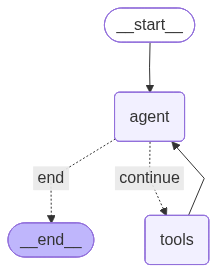

In [16]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            graph.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 6단계: ReAct Agent 사용해보기

이제 완성된 ReAct Agent를 실제로 사용해봅시다!

### 사용 방법
1. **입력**: 사용자 질문을 메시지 형태로 제공
2. **실행**: `graph.stream()`으로 단계별 실행
3. **출력**: 각 단계별 결과 확인


In [17]:
# 스트림을 예쁘게 출력하는 헬퍼 함수
def print_stream(stream):
    """
    그래프 실행 스트림을 보기 좋게 출력하는 함수
    """
    for step_output in stream:
        # 각 단계의 메시지 출력
        message = step_output["messages"][-1]

        if isinstance(message, tuple):
            print(message)
        else:
            # 메시지 타입에 따라 다르게 출력
            message.pretty_print()


### 예시 1: 날씨 조회

In [18]:
# 입력 메시지 설정
inputs = {"messages": [("user", "서울의 날씨가 어떤가요?")]}

print("ReAct Agent 실행 시작!\n")

try:
    # 그래프 실행 (스트림 모드로 단계별 확인)
    stream = graph.stream(inputs, stream_mode="values")
    print_stream(stream)

    print("\n첫 번째 예시 완료!")

except Exception as e:
    print(f"오류 발생: {str(e)}")
    print("API 키가 올바르게 설정되었는지 확인해주세요.")


ReAct Agent 실행 시작!

================================ Human Message =================================

서울의 날씨가 어떤가요?
AI 모델 노드 실행 중...
  총 2개의 메시지를 모델에 전달
  AI 응답 생성 완료 (도구 호출: 1개)
  1개의 도구 호출이 있으므로 계속 진행합니다
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_qVDQqcr50oUcEHG2zloP5UHA)
 Call ID: call_qVDQqcr50oUcEHG2zloP5UHA
  Args:
    city: 서울
도구 노드 실행 중...
  get_weather 도구 호출: {'city': '서울'}
  결과: 
        서울 날씨 정보:
        서울의 현재 기온은 섭씨 4.6도이고, 일기 예보에 따르면 맑은 날씨이며 최고 기온은 섭씨 33도이고, 기온이 크게 상승할 것으로 예상된다.

        출처: https://m.weatheri.co.kr/forecast/forecast10.php?mNum=1&sNum=8&pageNum=11
        
================================= Tool Message =================================
Name: get_weather

"\n        \uc11c\uc6b8 \ub0a0\uc528 \uc815\ubcf4:\n        \uc11c\uc6b8\uc758 \ud604\uc7ac \uae30\uc628\uc740 \uc12d\uc528 4.6\ub3c4\uc774\uace0, \uc77c\uae30 \uc608\ubcf4\uc5d0 \ub530\ub974\uba74 \ub9d1\uc740 \ub0a0\uc528\uc774\uba70 

### 예시 2: 복합 질문 (시간 + 계산)

In [19]:
inputs2 = {
    "messages": [
        ("user", "현재 시간을 알려주고, 25 * 4 + 10을 계산해주세요.")
    ]
}

print("복합 질문 처리 시작!\n")

try:
    stream2 = graph.stream(inputs2, stream_mode="values")
    print_stream(stream2)

    print("\n두 번째 예시 완료!")

except Exception as e:
    print(f"오류 발생: {str(e)}")


복합 질문 처리 시작!

================================ Human Message =================================

현재 시간을 알려주고, 25 * 4 + 10을 계산해주세요.
AI 모델 노드 실행 중...
  총 2개의 메시지를 모델에 전달
  AI 응답 생성 완료 (도구 호출: 2개)
  2개의 도구 호출이 있으므로 계속 진행합니다
================================== Ai Message ==================================
Tool Calls:
  get_current_time (call_OOJACQIfkTk9gVn9PRPygqqE)
 Call ID: call_OOJACQIfkTk9gVn9PRPygqqE
  Args:
  calculator (call_rEeLFwDN3wqLOltbtdevIc9j)
 Call ID: call_rEeLFwDN3wqLOltbtdevIc9j
  Args:
    expression: 25 * 4 + 10
도구 노드 실행 중...
  get_current_time 도구 호출: {}
  결과: 현재 시간: 2025년 11월 16일 08시 30분
  calculator 도구 호출: {'expression': '25 * 4 + 10'}
  결과: 계산 결과: 25 * 4 + 10 = 110
================================= Tool Message =================================
Name: calculator

"\uacc4\uc0b0 \uacb0\uacfc: 25 * 4 + 10 = 110"
AI 모델 노드 실행 중...
  총 5개의 메시지를 모델에 전달
  AI 응답 생성 완료 (도구 호출: 0개)
  도구 호출이 없으므로 대화를 종료합니다
================================== Ai Message =============================

### 예시 3: 일반 대화 (도구 사용 없음)

In [20]:
inputs3 = {
    "messages": [
        ("user", "안녕하세요! LangGraph에 대해 간단히 설명해주세요.")
    ]
}

print("일반 대화 처리 시작!\n")

try:
    stream3 = graph.stream(inputs3, stream_mode="values")
    print_stream(stream3)

    print("\n세 번째 예시 완료!")

except Exception as e:
    print(f"오류 발생: {str(e)}")


일반 대화 처리 시작!

================================ Human Message =================================

안녕하세요! LangGraph에 대해 간단히 설명해주세요.
AI 모델 노드 실행 중...
  총 2개의 메시지를 모델에 전달
  AI 응답 생성 완료 (도구 호출: 0개)
  도구 호출이 없으므로 대화를 종료합니다
================================== Ai Message ==================================

간단히 말해 LangGraph는 언어 데이터를 그래프 형태로 표현하고 분석하는 개념이나 도구를 말합니다.

주요 아이디어
- 그래프 구조: 노드는 언어 요소(단어, 구문 요소, 어휘 항목, 언어 자체 등), 엣지는 관계를 나타냅니다(의미 관계, 동의어/반의어, 구문 의존성, 번역 대응 등).
- 그래프 기반 학습: 그래프 이론이나 그래프 신경망(GNN)을 이용해 단어 간 관계나 다언어 간 연결성을 학습하고 활용합니다.
- 활용 영역: 다국어 NLP, 지식 그래프 구축, 의미 네트워크 분석, 어휘 자원 연결, 구문/의미 분석 등.

왜 유용한가
- 복잡한 관계를 직관적으로 모델링할 수 있습니다(단어 간 의미 관계나 다언어 매핑 등).
- 그래프 신경망을 통해 관계 정보를 효과적으로 전파하고 일반화할 수 있습니다.

도전 과제
- 그래프 구성의 품질과 스케일링 문제(데이터 품질, 노드/엣지 수 증가에 따른 처리 비용).
- 적절한 노드/엣지 타입과 가중치 설정의 중요성.

특정 LangGraph 프로젝트나 맥락이 있다면 알려주시면, 더 구체적으로 설명해 드리겠습니다.

세 번째 예시 완료!


## [7단계: Langsmith에서 확인하기](https://smith.langchain.com/)

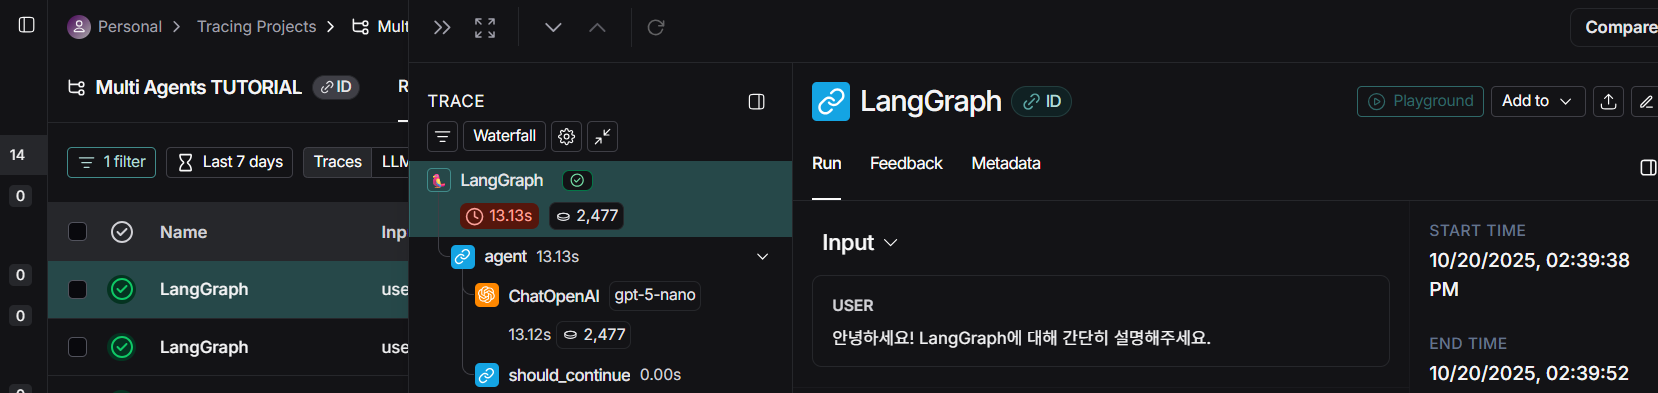